In [28]:
!pip install -r /Users/nutthaweecharoenngampis/Developer/sentiment-stock-predictor/requirements.txt

In [ ]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from datetime import datetime

tickers = ['NVDA']
data = yf.download(tickers, start="2015-07-21", end=datetime.now(), auto_adjust=False)
# Check the data
print(tabulate(data.tail(10), headers='keys', tablefmt='psql'))

[*********************100%***********************]  1 of 1 completed

+---------------------+-------------------------+---------------------+--------------------+-------------------+--------------------+----------------------+
| Date                |   ('Adj Close', 'NVDA') |   ('Close', 'NVDA') |   ('High', 'NVDA') |   ('Low', 'NVDA') |   ('Open', 'NVDA') |   ('Volume', 'NVDA') |
|---------------------+-------------------------+---------------------+--------------------+-------------------+--------------------+----------------------|
| 2025-07-23 00:00:00 |                  170.78 |              170.78 |             171.26 |            167.97 |             169.53 |          1.54082e+08 |
| 2025-07-24 00:00:00 |                  173.74 |              173.74 |             173.83 |            171.3  |             172.44 |          1.28985e+08 |
| 2025-07-25 00:00:00 |                  173.5  |              173.5  |             174.72 |            172.96 |             173.61 |          1.22317e+08 |
| 2025-07-28 00:00:00 |                  176.75 |         

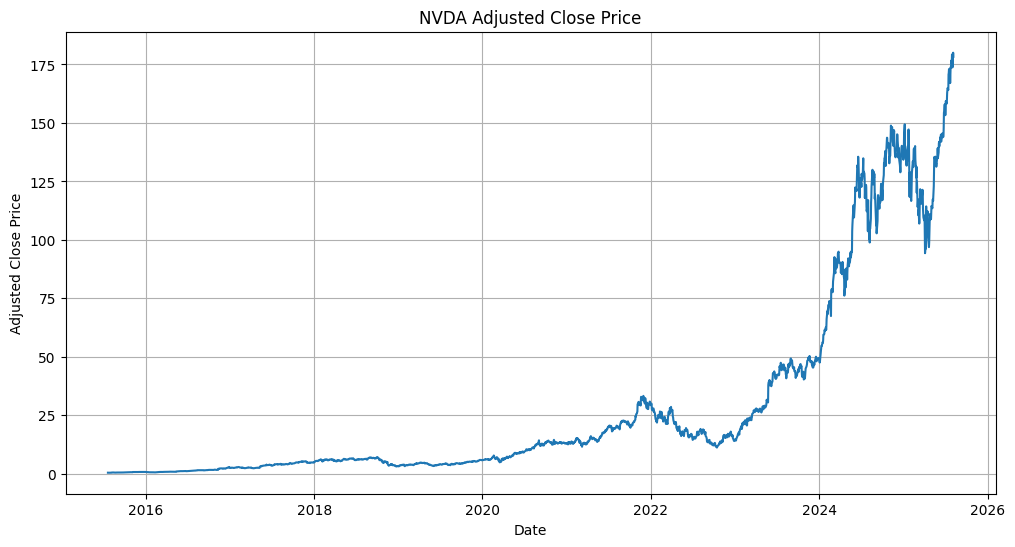

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, data[('Adj Close', 'NVDA')])
plt.title('NVDA Adjusted Close Price')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.grid(True)
plt.show()

### Train with DA-RNN old price

/Users/nutthaweecharoenngampis/Developer/sentiment-stock-predictor/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/Users/nutthaweecharoenngampis/Developer/sentiment-stock-predictor/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([12, 1])) that is different to the input size (torch.Size([12])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1, Loss: 0.0880
Epoch 2, Loss: 0.1084
Epoch 3, Loss: 0.1004
Epoch 4, Loss: 0.0591
Epoch 5, Loss: 0.0156
Epoch 6, Loss: 0.0054
Epoch 7, Loss: 0.0066
Epoch 8, Loss: 0.0059
Epoch 9, Loss: 0.0090
Epoch 10, Loss: 0.0112
Epoch 11, Loss: 0.0127
Epoch 12, Loss: 0.0052
Epoch 13, Loss: 0.0059
Epoch 14, Loss: 0.0059
Epoch 15, Loss: 0.0095
Epoch 16, Loss: 0.0137
Epoch 17, Loss: 0.0145
Epoch 18, Loss: 0.0053
Epoch 19, Loss: 0.0048
Epoch 20, Loss: 0.0055
Epoch 21, Loss: 0.0053
Epoch 22, Loss: 0.0085
Epoch 23, Loss: 0.0125
Epoch 24, Loss: 0.0130
Epoch 25, Loss: 0.0064
Epoch 26, Loss: 0.0091
Epoch 27, Loss: 0.0108
Epoch 28, Loss: 0.0113
Epoch 29, Loss: 0.0058
Epoch 30, Loss: 0.0078


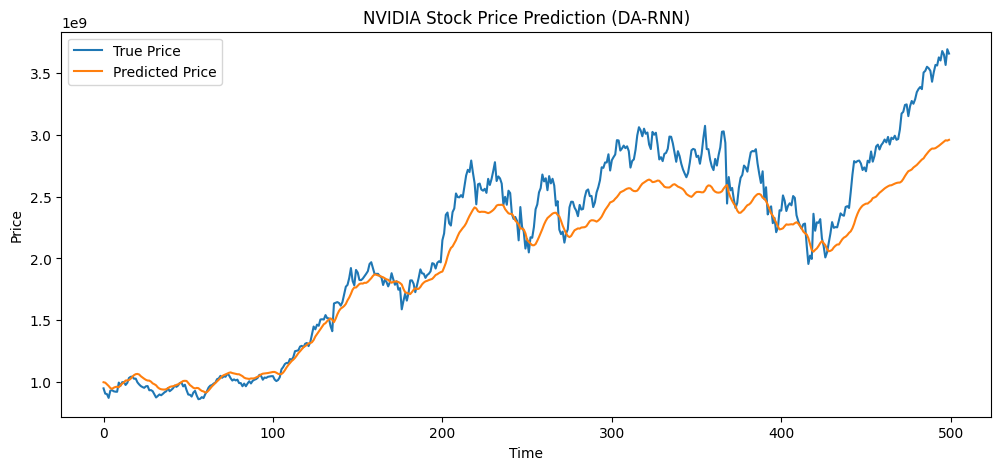

In [31]:
# Filter relevant features
df = data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.dropna(inplace=True)

# Normalize the data using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame for easier handling
scaled_df = pd.DataFrame(scaled_data, columns=df.columns, index=df.index)



def create_sequences(data, target_column, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:i+window_size].values)
        y.append(data.iloc[i+window_size][target_column])
    return np.array(X), np.array(y)

window_size = 30  # You can tune this
X, y = create_sequences(scaled_df, target_column='Close', window_size=window_size)



from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # Do not shuffle time series
)



import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)

    def forward(self, x):
        out, h = self.rnn(x)
        return out, h

class Decoder(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.rnn = nn.GRU(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, h):
        out, _ = self.rnn(x, h)
        out = self.fc(out[:, -1, :])
        return out

class DA_RNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.encoder = Encoder(input_size, hidden_size)
        self.decoder = Decoder(hidden_size)

    def forward(self, x):
        _, h = self.encoder(x)
        decoder_input = torch.zeros((x.size(0), 1, 1)).to(x.device)
        output = self.decoder(decoder_input, h)
        return output.squeeze()
    


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DA_RNN(input_size=X.shape[2], hidden_size=64).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_data = TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                           torch.tensor(y_train, dtype=torch.float32))
train_loader = DataLoader(train_data, batch_size=32, shuffle=False)

# Training loop
for epoch in range(30):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")



model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_pred = model(X_test_tensor).cpu().numpy()

# Rescale predictions
true = scaler.inverse_transform(np.concatenate([
    np.zeros((len(y_test), scaled_df.shape[1]-1)), y_test.reshape(-1,1)
], axis=1))[:, -1]

pred = scaler.inverse_transform(np.concatenate([
    np.zeros((len(y_pred), scaled_df.shape[1]-1)), y_pred.reshape(-1,1)
], axis=1))[:, -1]

plt.figure(figsize=(12,5))
plt.plot(true, label='True Price')
plt.plot(pred, label='Predicted Price')
plt.title('NVIDIA Stock Price Prediction (DA-RNN)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

### Future forecasting with DA-RNN

/var/folders/76/0r9x2xys7sb0vn337whbttxw0000gn/T/ipykernel_47898/463229258.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2025-01-01", end=datetime.now())
[*********************100%***********************]  1 of 1 completed


Epoch 1/20, Loss: 0.336942
Epoch 2/20, Loss: 0.351698
Epoch 3/20, Loss: 0.313822
Epoch 4/20, Loss: 0.257563
Epoch 5/20, Loss: 0.231384
Epoch 6/20, Loss: 0.179960
Epoch 7/20, Loss: 0.145124
Epoch 8/20, Loss: 0.086456
Epoch 9/20, Loss: 0.035850
Epoch 10/20, Loss: 0.038720
Epoch 11/20, Loss: 0.064710
Epoch 12/20, Loss: 0.041733
Epoch 13/20, Loss: 0.022817
Epoch 14/20, Loss: 0.019429
Epoch 15/20, Loss: 0.023913
Epoch 16/20, Loss: 0.024219
Epoch 17/20, Loss: 0.021962
Epoch 18/20, Loss: 0.016820
Epoch 19/20, Loss: 0.014545
Epoch 20/20, Loss: 0.009289


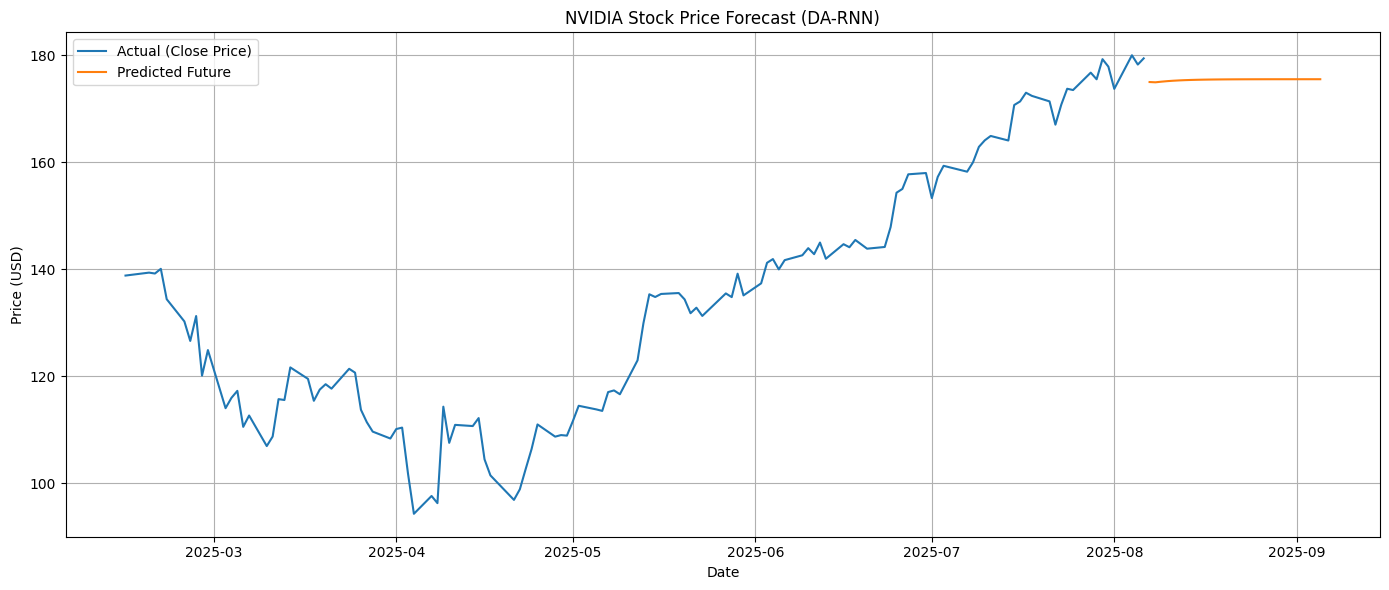

In [45]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------- 1. Load Data --------------------
ticker = 'NVDA'
df = yf.download(ticker, start="2025-01-01", end=datetime.now())
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df['MA7'] = df['Close'].rolling(window=7).mean()
df['MA30'] = df['Close'].rolling(window=30).mean()
df = df.dropna()

# -------------------- 2. Normalize --------------------
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# -------------------- 3. Dataset --------------------
class StockDataset(Dataset):
    def __init__(self, data, seq_len=30):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        seq = self.data[idx:idx + self.seq_len]
        target = self.data[idx + self.seq_len, 3]  # 'Close'
        return torch.FloatTensor(seq), torch.FloatTensor([target])

sequence_length = 30
dataset = StockDataset(scaled_data, seq_len=sequence_length)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# -------------------- 4. DA-RNN --------------------
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)

    def forward(self, x):
        _, (hidden, _) = self.rnn(x)
        return hidden

class Decoder(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.rnn = nn.LSTM(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, hidden):
        out, _ = self.rnn(x, (hidden, torch.zeros_like(hidden)))
        out = self.fc(out[:, -1])
        return out

input_size = scaled_data.shape[1]
hidden_size = 64

encoder = Encoder(input_size, hidden_size)
decoder = Decoder(hidden_size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder.to(device)
decoder.to(device)

# -------------------- 5. Train --------------------
def train_model(encoder, decoder, dataloader, epochs=20):
    enc_opt = torch.optim.Adam(encoder.parameters(), lr=0.001)
    dec_opt = torch.optim.Adam(decoder.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        total_loss = 0
        for seq, target in dataloader:
            seq, target = seq.to(device), target.to(device)
            hidden = encoder(seq)
            dec_input = seq[:, -1:, 3:4]  # last 'Close'
            pred = decoder(dec_input, hidden)
            loss = loss_fn(pred, target)

            enc_opt.zero_grad()
            dec_opt.zero_grad()
            loss.backward()
            enc_opt.step()
            dec_opt.step()

            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(dataloader):.6f}")

train_model(encoder, decoder, dataloader, epochs=20)

# -------------------- 6. Predict Future --------------------
def predict_future(n_future=30):
    last_seq = torch.FloatTensor(scaled_data[-sequence_length:]).unsqueeze(0).to(device)
    preds = []

    for _ in range(n_future):
        hidden = encoder(last_seq)
        last_close = last_seq[:, -1:, 3:4]  # last 'Close'
        pred = decoder(last_close, hidden)
        preds.append(pred.item())

        # Copy and update 'Close'
        new_row = last_seq[:, -1].clone()
        new_row[0, 3] = pred  # update 'Close'
        last_seq = torch.cat((last_seq[:, 1:], new_row.unsqueeze(1)), dim=1)

    return preds

future_preds = predict_future(n_future=30)

# -------------------- 7. Inverse Transform Predictions --------------------
# Build dummy array for inverse transform
dummy = np.zeros((len(future_preds), scaled_data.shape[1]))
dummy[:, 3] = future_preds  # Only set 'Close'
pred_prices = scaler.inverse_transform(dummy)[:, 3]

# -------------------- 8. Plot Full History + Future --------------------
plt.figure(figsize=(14, 6))
# Plot full real history
plt.plot(df.index, df['Close'], label='Actual (Close Price)')
# Future dates
future_dates = [df.index[-1] + timedelta(days=i+1) for i in range(len(pred_prices))]
# Plot future
plt.plot(future_dates, pred_prices, label='Predicted Future')
plt.title('NVIDIA Stock Price Forecast (DA-RNN)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1. Downloading stock data...


/var/folders/76/0r9x2xys7sb0vn337whbttxw0000gn/T/ipykernel_47898/3872594907.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


2. Adding Moving Average features...
3. Normalizing data...
4. Preparing dataset for training...
5. Initializing DA-RNN model...
6. Training model...
Epoch 1/20, Loss: 0.447064
Epoch 5/20, Loss: 0.199374
Epoch 10/20, Loss: 0.020776
Epoch 15/20, Loss: 0.027177
Epoch 20/20, Loss: 0.017043
7. Predicting future prices...
8. Inverse transforming predictions...
9. Generating plot...


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 3 dimension(s) and the array at index 1 has 2 dimension(s)

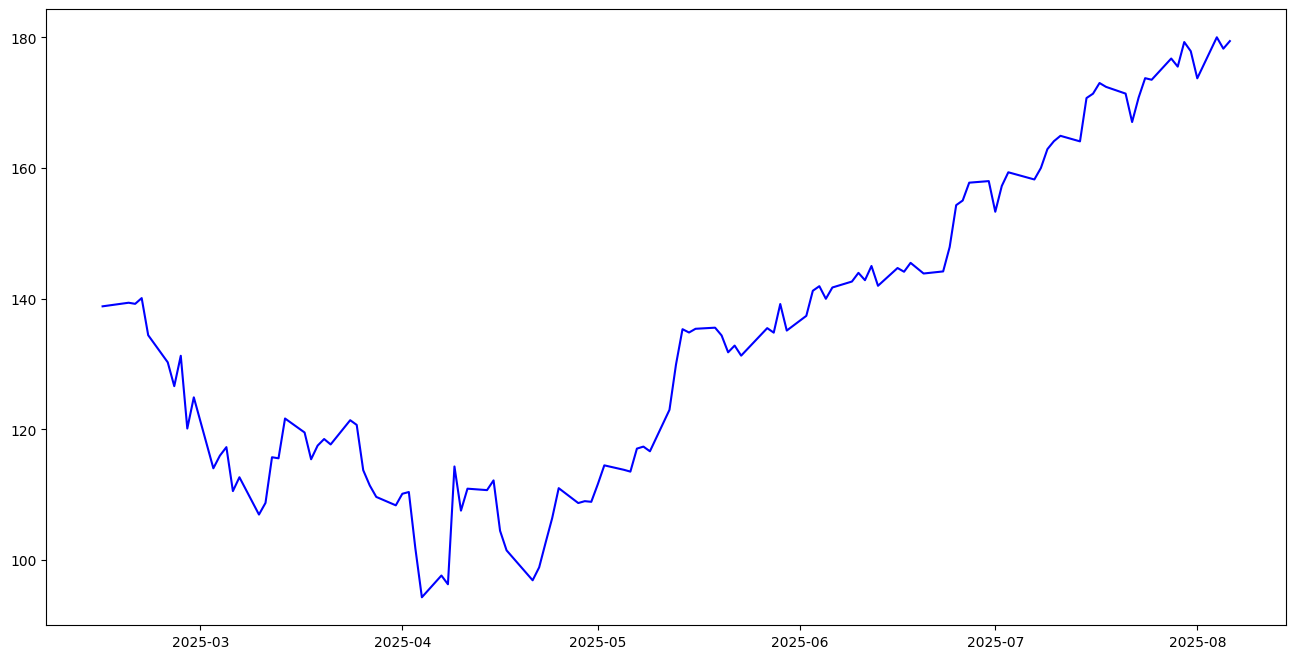

In [ ]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------- 1. Load Data --------------------
print("1. Downloading stock data...")
ticker = 'NVDA'
# The user's provided start date is "2025-01-01" which we will use.
# The end date will be the current day.
start_date = "2025-01-01"
end_date = datetime.now()

# Download data for NVDA from the specified start date to the present
df = yf.download(ticker, start=start_date, end=end_date)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

# -------------------- 2. Feature Engineering (add MA7 and MA30) --------------------
# Moving Averages are common technical indicators used in stock analysis.
print("2. Adding Moving Average features...")
df['MA7'] = df['Close'].rolling(window=7).mean()
df['MA30'] = df['Close'].rolling(window=30).mean()
df = df.dropna()

# -------------------- 3. Normalize Data --------------------
# We need to normalize the data so that the neural network can learn
# more effectively without being biased by large values (like Volume).
print("3. Normalizing data...")
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# We'll also create a scaler for just the 'Close' price to inverse transform predictions later.
close_scaler = MinMaxScaler()
close_scaler.fit(df[['Close']])

# -------------------- 4. Create Dataset and DataLoader --------------------
# The StockDataset class prepares our data into sequences for the model.
# The DataLoader handles batching and shuffling.
print("4. Preparing dataset for training...")
class StockDataset(Dataset):
    def __init__(self, data, seq_len=30):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        # The input is a sequence of length `seq_len`
        seq = self.data[idx:idx + self.seq_len]
        # The target is the 'Close' price one step after the sequence ends.
        target = self.data[idx + self.seq_len, 3] # 'Close' is the 4th column (index 3)
        return torch.FloatTensor(seq), torch.FloatTensor([target])

sequence_length = 30
dataset = StockDataset(scaled_data, seq_len=sequence_length)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False)

# -------------------- 5. Define DA-RNN Model --------------------
# This DA-RNN architecture is based on the second code block you provided,
# but adapted to be a single class for better organization.
print("5. Initializing DA-RNN model...")
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        # Using a GRU as per the second code block, which can be faster than LSTM
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)

    def forward(self, x):
        out, h = self.rnn(x)
        return h # Return the final hidden state

class Decoder(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        # The decoder takes a single input (the predicted close price from the previous step)
        self.rnn = nn.GRU(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, h):
        # We use the hidden state from the encoder as the initial hidden state for the decoder.
        out, h = self.rnn(x.unsqueeze(1), h)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

# The main DA-RNN class
class DA_RNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.encoder = Encoder(input_size, hidden_size)
        self.decoder = Decoder(hidden_size)

    def forward(self, x):
        h = self.encoder(x)
        # For training, we predict the next close price.
        # The decoder takes a single value, so we'll use a dummy input for the first step
        # and rely on the hidden state from the encoder.
        decoder_input = torch.zeros((x.size(0), 1)).to(x.device)
        output = self.decoder(decoder_input, h)
        return output

input_size = scaled_data.shape[1]
hidden_size = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DA_RNN(input_size=input_size, hidden_size=hidden_size).to(device)

# -------------------- 6. Train Model --------------------
print("6. Training model...")
epochs = 20
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_model(model, dataloader, epochs):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for seq, target in dataloader:
            seq, target = seq.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(seq)
            loss = criterion(output, target.squeeze())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(dataloader):.6f}")

train_model(model, dataloader, epochs)

# -------------------- 7. Predict Future Prices --------------------
# This function iteratively predicts future prices using the trained model.
print("7. Predicting future prices...")
def predict_future(model, last_seq, n_future=30):
    model.eval()
    last_seq = last_seq.to(device)
    preds = []

    with torch.no_grad():
        for _ in range(n_future):
            # Pass the sequence through the encoder to get the hidden state
            hidden = model.encoder(last_seq)

            # Get the predicted price from the decoder
            decoder_input = torch.zeros((1, 1)).to(device) # The decoder needs an initial input
            pred = model.decoder(decoder_input, hidden)
            
            preds.append(pred.item())
            
            # The next sequence is the old sequence shifted, with the new prediction appended.
            # We need to simulate the features for the next day. A simple way is to
            # assume the Open, High, Low, Volume, MA7, and MA30 for the next day
            # are the same as the last known day.
            new_row = last_seq[0, -1, :].clone().detach()
            new_row[3] = pred.item() # Update the 'Close' price with the prediction.
            
            # Recalculate MA7 and MA30 based on the new 'Close' price, this is a
            # simplification and may not be accurate. For a real application,
            # a more sophisticated approach is needed.
            # Here we just use a simple shift.
            
            # Append the new row to the sequence
            last_seq = torch.cat((last_seq[:, 1:, :], new_row.unsqueeze(0).unsqueeze(0)), dim=1)

    return preds

last_sequence = scaled_data[-sequence_length:]
last_sequence = torch.FloatTensor(last_sequence).unsqueeze(0).to(device)
future_preds_scaled = predict_future(model, last_sequence, n_future=30)

# -------------------- 8. Inverse Transform Predictions --------------------
# We need to convert the normalized predictions back to actual dollar values.
print("8. Inverse transforming predictions...")
future_preds_scaled = np.array(future_preds_scaled).reshape(-1, 1)
future_preds_original = close_scaler.inverse_transform(future_preds_scaled)

# -------------------- 9. Plotting the Results --------------------
print("9. Generating plot...")

# Combine the historical and predicted dates for a continuous x-axis
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=30, freq='B')
combined_dates = df.index.tolist() + future_dates.tolist()

# Combine the historical and predicted prices for a continuous y-axis
last_historical_price = df['Close'].iloc[-1].item()
combined_prices = df['Close'].values.tolist() + future_preds_original.flatten().tolist()

plt.figure(figsize=(16, 8))
# Plot the full combined data.
# The split is handled by setting different colors and line styles.
plt.plot(df.index, df['Close'], label='Historical Stock Price', color='blue')
# Plot the predicted prices, starting from the last historical point.
# New line 199
plt.plot(pd.Index([last_date]).append(future_dates), np.concatenate((np.array([[last_historical_price]]), future_preds_original)),
         label='Predicted Future Price', color='red', linestyle='--')

plt.title(f'{ticker} Stock Price Prediction with DA-RNN', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price (USD)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()